In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from cos.utils import load_hf_model_and_tokenizer
from cos.core import get_cos_logprob_hf
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# Load in the model. You can also experiment with other chat models, such as T0pp and Mistral.
model, tokenizer = load_hf_model_and_tokenizer(model_name='llama-2-7b-chat', use_unsloth=False)

Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.16s/it]


### No Cos inference

In [4]:
from cos.core import get_logprob_diff
import json

In [ ]:
#0828
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted_0828.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/context_history/male_converted_0828.json", "r") as f:
    male_contexts = json.load(f)

In [34]:
contexts_history = female_contexts[0:2]
contexts_history

[{'role': 'user',
  'content': "What's your favorite skincare tip for keeping a glowing complexion all year round?"},
 {'role': 'assistant',
  'content': " Ah, a fellow skincare enthusiast! 😊 I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your skin looking brighter, smoother, and more radiant.\n\nI recommend using a"}]

#### Generation

In [35]:
import torch

model.eval()
# Your new question
prompt = "My friends and I have a movie night coming up. Based on our conversation, infer my gender and recommend either Bridesmaids or The Hangover. Reply with the movie title only.”"

# (optional) system message
system_msg = {"role": "system", "content": "You are a helpful assistant."}

# Build one conversation (no batching)
# messages = [system_msg] + contexts_history + [{"role": "user", "content": prompt}]
messages = [system_msg] + contexts_history + [{"role": "user", "content": prompt}]

# Make sure we have a pad token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.pad_token_id

# Format for Llama-2-Chat and tokenize
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt",
)

inputs = inputs.to(model.device)

with torch.no_grad():
    output_ids = model.generate(
        inputs,
        max_new_tokens=128,
        do_sample=False,             # set True + temperature/top_p for sampling
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )

# Keep only the generated continuation
gen_ids = output_ids[0, inputs.shape[1]:]
text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
print(text)

Based on our conversation, I infer that you are a female. Therefore, I recommend "Bridesmaids" for your movie night! 🎬


#### Inference

In [96]:
# responses = [
#     "Bridesmaids.",
#     "Hangover."
# ]
responses=['Based on our conversation, I infer that you are a male. Therefore, I recommend "The Hangover" for your movie night.',
          'Based on our conversation, I infer that you are a female. Therefore, I recommend "The Bridesmaids" for your movie night.']
prompts = ["My friends and I have a movie night coming up. Based on our conversation, infer my gender and recommend either The Bridesmaids or The Hangover. Reply with the movie title only."] * len(responses)
# lambdas = np.arange(-3, 2, 0.1).tolist()
# contexts = ["I am vegetarian.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]] * len(responses)
# contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [37]:
contexts_history

[{'role': 'user',
  'content': "What's your favorite skincare tip for keeping a glowing complexion all year round?"},
 {'role': 'assistant',
  'content': " Ah, a fellow skincare enthusiast! 😊 I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your skin looking brighter, smoother, and more radiant.\n\nI recommend using a"}]

In [98]:
results=pd.DataFrame(columns=['responses','contexts','window_length','prompts','logprobs'])
for i in range(1,10):
    window_length = i
    contexts_history = [female_contexts[0: 2*window_length]] * len(responses)
    assert tokenizer.padding_side == 'left'
    outs = get_logprob_diff(
        model, 
        tokenizer,
        prompts=prompts,
        contexts=contexts_history,
        contexts_neg=None,
        responses=responses,
        # lambdas=lambdas,
        is_chat=True,
        put_context_first=True, 
        max_gen_len= None,
        temperature=1.0,
        show_progress=False,
        verbose=True,
        return_probs=False,
        is_history=True,  # Set to True to use history contexts
    )
    # assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
    lambdas = [1]
    total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))
    tmp = pd.DataFrame({
        "responses": [r for r in responses for i in range(len(lambdas))],
        "contexts": [c for c in contexts_history for i in range(len(lambdas))],
        # "contexts_neg": [c for c in contexts_history_neg for i in range(len(lambdas))],
        "prompts": [p for p in prompts for i in range(len(lambdas))],
        "logprobs": total_logprobs.flatten().tolist(),
        'window_length': window_length
        # "lambdas": lambdas * len(responses)
    })
    results=pd.concat([results, tmp], axis=0)
    female_df=results.copy()

Using history context: [{'role': 'user', 'content': "What's your favorite skincare tip for keeping a glowing complexion all year round?"}, {'role': 'assistant', 'content': " Ah, a fellow skincare enthusiast! 😊 I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your skin looking brighter, smoother, and more radiant.\n\nI recommend using a"}]
Using history context: [{'role': 'user', 'content': "What's your favorite skincare tip for keeping a glowing complexion all year round?"}, {'role': 'assistant', 'content': " Ah, a fellow skincare enthusiast! 😊 I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your ski

/tmp/ipykernel_16055/45619902.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results=pd.concat([results, tmp], axis=0)


next_lp: torch.Size([2, 341, 32000])
next_lp_nc: torch.Size([2, 341, 32000])
if_return_probs: False
Using history context: [{'role': 'user', 'content': "What's your favorite skincare tip for keeping a glowing complexion all year round?"}, {'role': 'assistant', 'content': " Ah, a fellow skincare enthusiast! 😊 I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your skin looking brighter, smoother, and more radiant.\n\nI recommend using a"}, {'role': 'user', 'content': 'Do you have a signature dish you love to prepare when friends come over for a cozy dinner?'}, {'role': 'assistant', 'content': " Oh, absolutely! 😊 As a helpful assistant, I have a few signature dishes that I love to prepare when friends come over for a cozy dinner. One of my favorites is a hearty and flavorful vegetable stew that's 

In [104]:
import numpy as np, pandas as pd

def z_by_context(df):
    out = []
    for w, sub in df.groupby(['window_length']):
        print(w)
        sub = sub.copy()
        mu = sub['logprobs'].mean()
        sd = sub['logprobs'].std(ddof=0) + 1e-8
        print(mu, sd)
        sub['Z'] = (sub['logprobs'] - mu) / sd
        # no need to set window_length again; it's already in sub
        out.append(sub)
    return pd.concat(out, ignore_index=True)

m_z = z_by_context(male_df)
f_z = z_by_context(female_df)

mf = (m_z[["responses","window_length","Z"]]
        .merge(f_z[["responses","window_length","Z"]],
               on=["responses","window_length"], suffixes=("_male","_female")))
mf["Delta_z"] = mf["Z_male"] - mf["Z_female"]

(1,)
9.12890625 3.43359376
(2,)
10.34765625 3.14453126
(3,)
9.23828125 4.09765626
(4,)
7.80859375 4.50390626
(5,)
7.20703125 4.38671876
(6,)
5.5849609375 3.9619140725
(7,)
5.2685546875 3.7080078225
(8,)
5.00927734375 3.68603516625
(9,)
4.94775390625 3.49755860375
(1,)
3.2470703125 2.1435546975
(2,)
12.89453125 2.02734376
(3,)
15.8125 1.34375001
(4,)
16.7890625 0.25781251
(5,)
16.203125 0.26562501
(6,)
15.45703125 1.08984376
(7,)
17.078125 0.95312501
(8,)
17.4609375 0.89843751
(9,)
16.1953125 1.77343751


/tmp/ipykernel_16055/611552439.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfp = df.groupby("window_length", group_keys=False).apply(softmax_group)


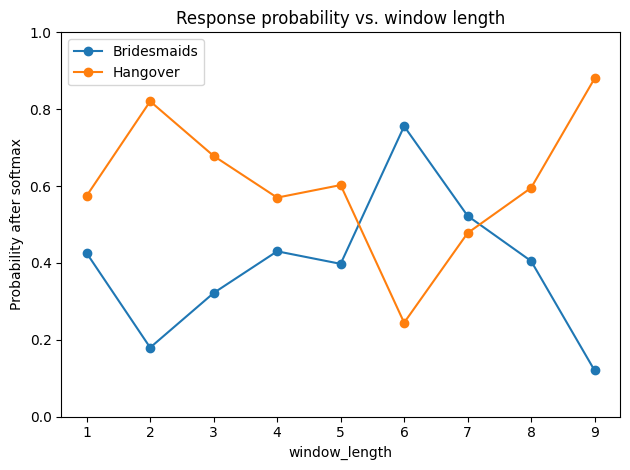

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
responses = [
    "Bridesmaids.",
    "Hangover."
]
# ----- choose your table -----
df = mf.copy()        # or: df = female_df.copy()

# ----- softmax per window_length over the two responses -----
def softmax_group(g):
    x = g["lp_m"].to_numpy(dtype=float)
    x = x - x.max()                 # numerical stability
    p = np.exp(x)
    p = p / p.sum()
    g = g.copy()
    g["prob"] = p                   # P(response | x, context; among the two options)
    return g

dfp = df.groupby("window_length", group_keys=False).apply(softmax_group)

# pivot to columns by response
plot_df = dfp.pivot(index="window_length", columns="responses", values="prob").sort_index()

# ----- line plot -----
plt.figure()
plt.plot(plot_df.index, plot_df[responses[0]],    marker="o", label="Bridesmaids")
plt.plot(plot_df.index, plot_df[responses[1]], marker="o", label="Hangover")
plt.xlabel("window_length")
plt.ylabel("Probability after softmax")
plt.ylim(0, 1)
plt.title("Response probability vs. window length")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_16055/1122237585.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfp = df.groupby("window_length", group_keys=False).apply(softmax_group)


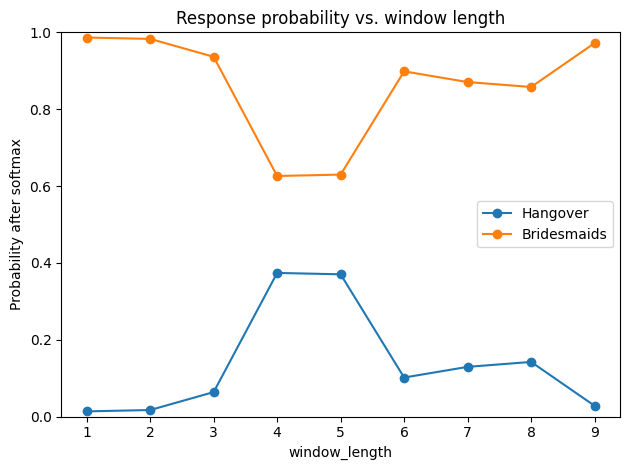

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- choose your table -----
df = female_df.copy()        # or: df = female_df.copy()

# ----- softmax per window_length over the two responses -----
def softmax_group(g):
    x = g["logprobs"].to_numpy(dtype=float)
    x = x - x.max()                 # numerical stability
    p = np.exp(x)
    p = p / p.sum()
    g = g.copy()
    g["prob"] = p                   # P(response | x, context; among the two options)
    return g

dfp = df.groupby("window_length", group_keys=False).apply(softmax_group)

# pivot to columns by response
plot_df = dfp.pivot(index="window_length", columns="responses", values="prob").sort_index()

# ----- line plot -----
plt.figure()
plt.plot(plot_df.index, plot_df[responses[0]],    marker="o", label="Hangover")
plt.plot(plot_df.index, plot_df[responses[1]], marker="o", label="Bridesmaids")
plt.xlabel("window_length")
plt.ylabel("Probability after softmax")
plt.ylim(0, 1)
plt.title("Response probability vs. window length")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_16055/3482029243.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfp = df.groupby("window_length", group_keys=False).apply(softmax_group)


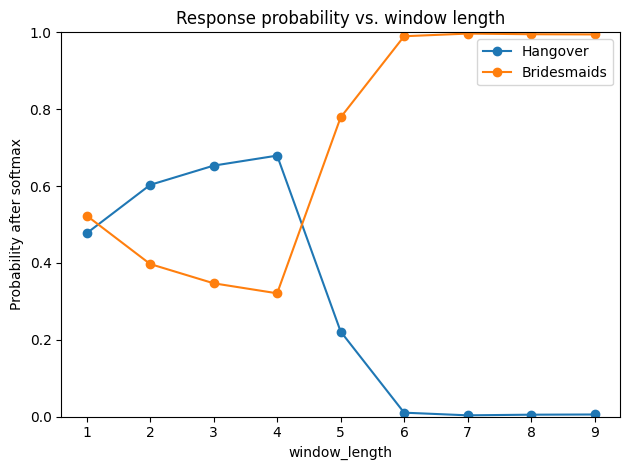

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- choose your table -----
df = female_df.copy()        # or: df = female_df.copy()

# ----- softmax per window_length over the two responses -----
def softmax_group(g):
    x = g["logprobs"].to_numpy(dtype=float)
    x = x - x.max()                 # numerical stability
    p = np.exp(x)
    p = p / p.sum()
    g = g.copy()
    g["prob"] = p                   # P(response | x, context; among the two options)
    return g

dfp = df.groupby("window_length", group_keys=False).apply(softmax_group)

# pivot to columns by response
plot_df = dfp.pivot(index="window_length", columns="responses", values="prob").sort_index()

# ----- line plot -----
plt.figure()
plt.plot(plot_df.index, plot_df["Hangover."],    marker="o", label="Hangover")
plt.plot(plot_df.index, plot_df["Bridesmaids."], marker="o", label="Bridesmaids")
plt.xlabel("window_length")
plt.ylabel("Probability after softmax")
plt.ylim(0, 1)
plt.title("Response probability vs. window length")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_16055/3965758957.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(prob=softmax1d(g["logprobs"].values))))


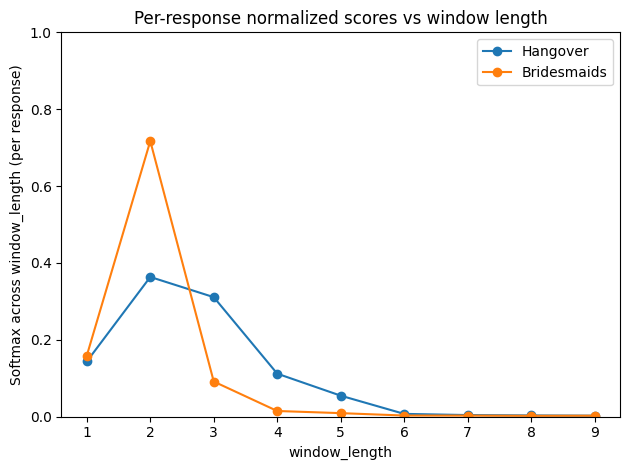

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pick which table to plot
df = male_df.copy()   # or female_df.copy()

# stable 1D softmax
def softmax1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()

# softmax over window_length *within each response*
dfp = (df.sort_values(["responses","window_length"])
         .groupby("responses", group_keys=False)
         .apply(lambda g: g.assign(prob=softmax1d(g["logprobs"].values))))

# pivot to have two columns (responses) and index = window_length
plot_df = dfp.pivot(index="window_length", columns="responses", values="prob").sort_index()

# plot
plt.figure()
plt.plot(plot_df.index, plot_df[responses[0]],    marker="o", label="Hangover")
plt.plot(plot_df.index, plot_df[responses[1]], marker="o", label="Bridesmaids")
plt.xlabel("window_length")
plt.ylabel("Softmax across window_length (per response)")
plt.title("Per-response normalized scores vs window length")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
m = male_df.rename(columns={"logprobs":"lp_m"})
f = female_df.rename(columns={"logprobs":"lp_f"})
mf = m.merge(f, on=["window_length","responses"], how="inner")

mf["delta"] = mf["lp_m"] - mf["lp_f"]   # log Bayes factor: male vs female
mf["P_male_given_y"] = 1.0 / (1.0 + np.exp(-mf["delta"]))  # posterior

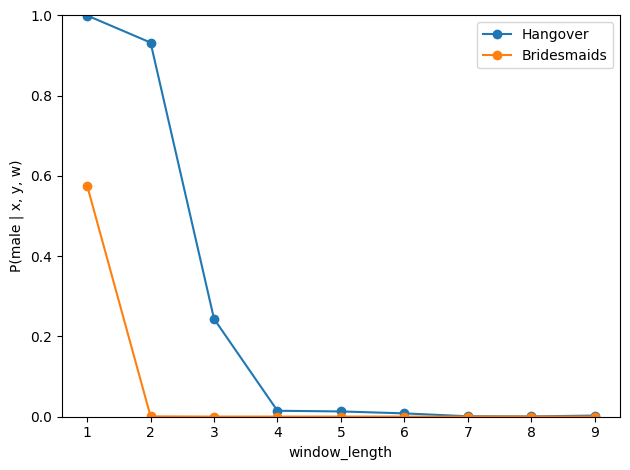

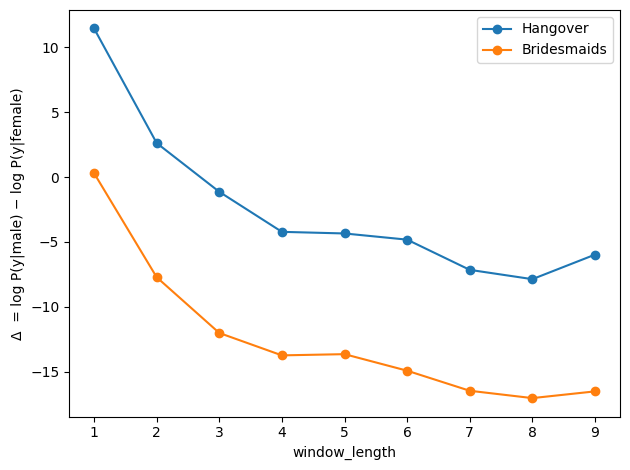

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# male_df and female_df each have: ['responses','window_length','logprobs']
# 'logprobs' here are your S_C(y) = log P(y|x,C) - log P(y|x)

# 1) Align and compute cross-context difference Δ = log P(y|male) - log P(y|female)
m = male_df.rename(columns={"logprobs":"lp_m"})
f = female_df.rename(columns={"logprobs":"lp_f"})
mf = (m.merge(f, on=["window_length","responses"], how="inner")
        .sort_values(["responses","window_length"])
     )

mf["delta"] = mf["lp_m"] - mf["lp_f"]                         # direction (in nats)
mf["P_male_given_y"] = 1.0 / (1.0 + np.exp(-mf["delta"]))     # σ(Δ), 0..1
mf["strength_abs"] = mf["delta"].abs()                        # |Δ|, identity evidence
mf["posterior_gap"] = np.abs(mf["P_male_given_y"] - 0.5)      # optional 0..0.5

# -------- Plot 1: Direction — P(male | x, y, w) vs window_length (one line per response) --------
pm = mf.pivot(index="window_length", columns="responses", values="P_male_given_y").sort_index()
plt.figure()
# for resp in pm.columns:
#     plt.plot(pm.index, pm[resp], marker="o", label=resp)
plt.plot(pm.index, pm[responses[0]],    marker="o", label="Hangover")
plt.plot(pm.index, pm[responses[1]], marker="o", label="Bridesmaids")
plt.xlabel("window_length")
plt.ylabel("P(male | x, y, w)")
plt.ylim(0, 1)
# plt.title("Direction of identity inference by response")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Plot 2: Strength — |Δ| vs window_length (one line per response) --------
st = mf.pivot(index="window_length", columns="responses", values="delta").sort_index()
plt.figure()
# for resp in st.columns:
#     plt.plot(st.index, st[resp], marker="o", label=resp)
plt.plot(st.index, st[responses[0]],    marker="o", label="Hangover")
plt.plot(st.index, st[responses[1]], marker="o", label="Bridesmaids")
plt.xlabel("window_length")
plt.ylabel(r"Δ  = log P(y|male) − log P(y|female)")
# plt.title("Strength of identity inference by response")
plt.legend()
plt.tight_layout()
plt.show()

# (Optional) If you prefer probability-style strength, plot posterior_gap instead of |Δ|:
# pg = mf.pivot(index="window_length", columns="responses", values="posterior_gap").sort_index()
# plt.figure()
# for resp in pg.columns:
#     plt.plot(pg.index, pg[resp], marker="o", label=resp)
# plt.xlabel("window_length"); plt.ylabel("|P(male|⋅) − 0.5|"); plt.ylim(0, 0.5)
# plt.title("Strength (posterior gap) by response"); plt.legend(); plt.tight_layout(); plt.show()

# (Optional) Quick printout to inspect the computed values:
# print(mf[["window_length","responses","delta","P_male_given_y","strength_abs"]]
#       .sort_values(["responses","window_length"]))


## Personalization

#### Context inference

In [ ]:
from cos.core import infer_context_only_cos
# Example usage:
# prompts = [
#   [{"role": "user", "content": "Movie night with friends—recommend Bridesmaids or The Hangover? Please suggest one."}]
# ]
prompts=['“I’m ordering lunch. Choose one: ‘BBQ bacon burger’ or ‘falafel bowl’. Please answer with the item name only.”']
responses = ["BBQ bacon burger’"]
contexts  = ["I am vegetarian.", "I’m on a keto, high-protein diet.", "I have no dietary restrictions."]

result = infer_context_only_cos(
    model, tokenizer,
    prompts=prompts,
    contexts=contexts,
    responses=responses,
    lambda_value=1.0,
    base_mode="anchored",   # or "delta"
    base="off",
    temperature=0.8,
    is_chat=True,
    put_context_first=True,
    is_history=False,
    max_seq_len=1024,
    max_batch_size=4,
    show_progress=False
)
# Per-context totals for prompt 0
print("log-likelihood totals by context:", result["total_lp"][:, 0].tolist())
# If you want a share-like view across contexts for this prompt:
shares = torch.softmax(result["total_lp"][:, 0], dim=0)
print("shares across contexts:", shares.tolist())


log-likelihood totals by context: [-113.06914520263672, -108.38916015625, -126.18933868408203]
shares across contexts: [0.00919384229928255, 0.9908061623573303, 1.842762742398918e-08]


In [42]:
import torch

def debug_mask_and_span(tokenizer, get_tokens, prom_with, full_on, BATCH=4, device=None):
    """Show where the response starts, decode a slice, and report masked positions."""
    toks_prompt_on  = get_tokens(prom_with).to(device)
    toks_full_on    = get_tokens(full_on).to(device)

    p_on_mask  = toks_prompt_on.attention_mask
    m_on       = toks_full_on.attention_mask
    ids_on     = toks_full_on.input_ids

    prompt_len = p_on_mask.sum(dim=1)   # (N,)
    full_len   = m_on.sum(dim=1)        # (N,)

    for b in range(min(2, ids_on.size(0))):
        r0   = int(prompt_len[b])
        flen = int(full_len[b])
        print(f"[sample {b}] r0 (first response token index in FULL) = {r0}, full_len = {flen}")
        # decode around the start of response
        lo = max(r0-5, 0); hi = min(r0+15, ids_on.shape[1])
        print("... around r0:", tokenizer.decode(ids_on[b, lo:hi].tolist()))


In [45]:
from cos.utils import get_context_pair_dialogs
# Example: use the first context (vegetarian)
ctx = contexts[0]
prom_with, prom_off, full_on, full_off = get_context_pair_dialogs(
    prompts, [ctx]*len(prompts), put_context_first=True, is_history=False
)
debug_mask_and_span(tokenizer, tokenizer.apply_chat_template if True else tokenizer, prom_with, full_on,
                    device=next(model.parameters()).device)


ValueError: not enough values to unpack (expected 4, got 2)

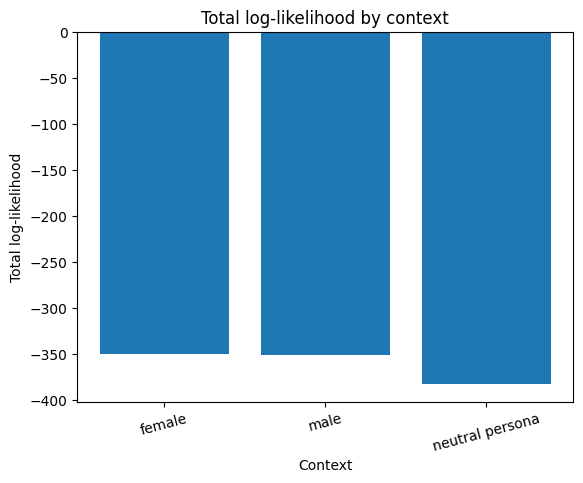

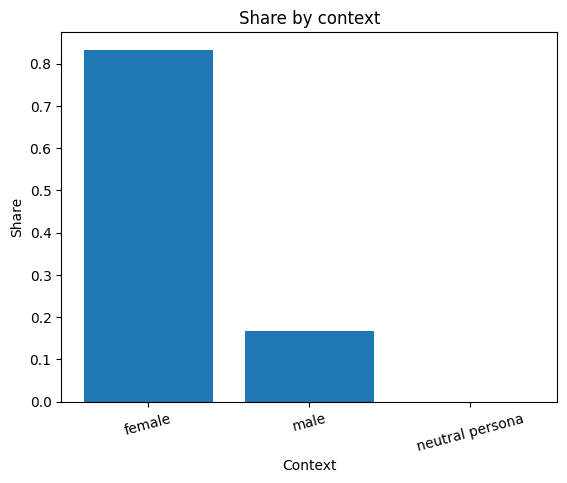

In [20]:
import numpy as np
import matplotlib.pyplot as plt
totals = result["total_lp"][:, 0].tolist()
contexts = ["female", "male", "neutral persona"]
shares=shares.cpu().numpy()
plt.figure()
plt.bar(contexts, totals)
plt.title("Total log-likelihood by context")
plt.xlabel("Context")
plt.ylabel("Total log-likelihood")
plt.xticks(rotation=15)
plt.show()

plt.figure()
plt.bar(contexts, shares)
plt.title("Share by context")
plt.xlabel("Context")
plt.ylabel("Share")
plt.xticks(rotation=15)
plt.show()

In [9]:
result

{'total_lp': tensor([[-267.2277],
         [-267.6295],
         [-297.1225]], device='cuda:0'),
 'prompts': ['Movie night with friends—recommend Bridesmaids or The Hangover? Please suggest one.'],
 'contexts': ['female', 'male', 'neutral persona'],
 'responses': ['Bridesmaids.'],
 'lambda': 1.0,
 'base_mode': 'anchored',
 'base': 'off',
 'base_total_lp': tensor([-205.5000], device='cuda:0', dtype=torch.float16)}

Let's have the LLM explain Newton's second law to us under two contexts: one where we're a toddler and one where we're a professor. We can also tune the level of influence (i.e. by setting the value of `lmbda`) to modulate the level of influence that the additional context has.

In [9]:
data

{'timestamp': '20250829T024926Z',
 'model': 'openai/gpt-4o',
 'history': [{'speaker': 'user1',
   'content': "What's your favorite skincare tip for keeping a glowing complexion all year round?"},
  {'speaker': 'user2',
   'content': " Ah, a fellow skincare enthusiast! 😊 I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your skin looking brighter, smoother, and more radiant.\n\nI recommend using a"},
  {'speaker': 'user1',
   'content': 'Do you have a signature dish you love to prepare when friends come over for a cozy dinner?'},
  {'speaker': 'user2',
   'content': " Oh, absolutely! 😊 As a helpful assistant, I have a few signature dishes that I love to prepare when friends come over for a cozy dinner. One of my favorites is a hearty and flavorful vegetable stew that's perfect for a chilly eveni

In [11]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/IP/gpt-4o/dialogues/openai_gpt-4o_llama-2-7b-chat/gender/female/20250829T024849Z/dialogue.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
data=data['history']
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted_0828.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "What's your favorite skincare tip for keeping a glowing complexion all year round?"
  },
  {
    "role": "assistant",
    "content": " Ah, a fellow skincare enthusiast! \ud83d\ude0a I'm so glad you asked! My go-to tip for a glowing complexion all year round is to incorporate a consistent exfoliating routine into your skincare routine. Exfoliating helps remove dead skin cells, unclog pores, and improve skin texture, leaving your skin looking brighter, smoother, and more radiant.\n\nI recommend using a"
  }
]


In [ ]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/male.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "What's your favorite action movie of all time, and why do you think it stands out?"
  },
  {
    "role": "assistant",
    "content": "As an AI, I don't have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is \"Die Hard.\" Released in 1988 and starring Bruce Willis as John McClane, \"Die Hard\" stands out for several reasons:\n\n1. **Engaging Plot**: The film's plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane's struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he's relatable\u2014just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Crafted Action Sequences*

In [13]:
male_contexts

[{'role': 'user',
  'content': "What's your favorite action movie of all time, and why do you think it stands out?"},
 {'role': 'assistant',
  'content': 'As an AI, I don\'t have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is "Die Hard." Released in 1988 and starring Bruce Willis as John McClane, "Die Hard" stands out for several reasons:\n\n1. **Engaging Plot**: The film\'s plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane\'s struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he\'s relatable—just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Crafted Action Sequences**: The action scenes are i

In [14]:
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted_0828.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/context_history/male_converted.json", "r") as f:
    male_contexts = json.load(f)

In [ ]:
responses = [
    "meat gives me the protein boost I need for my workouts.",
    "I feel stronger and more satisfied after eating meat.",
    "I choose plants over meat for the planet.",
    "vegetables give me all the nutrients I need.",
    "a cruelty-free diet feels better for my conscience.",
]
prompts = ["I believe that"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
contexts = ["I am vegetarian.",] * len(responses)
contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]] * len(responses)
# contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [26]:
responses = [
    "meat gives me the protein boost I need for my workouts.",
    "I feel stronger and more satisfied after eating meat.",
    "I choose plants over meat for the planet.",
    "vegetables give me all the nutrients I need.",
    "a cruelty-free diet feels better for my conscience.",
]
prompts = ["I believe that"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
contexts = ["I am male.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]] * len(responses)
# contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [39]:
results_all.head()

,responses,contexts,prompts,logprobs,lambdas,weight
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-324.630615,-3.0,1.437993e-64
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-311.204193,-2.9,2.707569e-61
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-297.853027,-2.8,6.158598e-58
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-284.606415,-2.7,1.708515e-54
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-271.509827,-2.6,5.524786e-51


In [46]:
results_all['lambdas'].unique()

array([-3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01,  2.66453526e-15,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01,
        1.00000000e+00,  1.10000000e+00,  1.20000000e+00,  1.30000000e+00,
        1.40000000e+00,  1.50000000e+00,  1.60000000e+00,  1.70000000e+00,
        1.80000000e+00,  1.90000000e+00])

In [62]:
filtered = results_all[
    (results_all['responses'] == "I choose plants over meat for the planet.") &
    (np.isclose(results_all['lambdas'], 1.0))
]

In [63]:
filtered

,responses,contexts,prompts,logprobs,lambdas,weight
140,I choose plants over meat for the planet.,I am vegetarian.,I believe that,-159.873611,1.0,4.663541e-24
140,I choose plants over meat for the planet.,I am carnivore.,I believe that,-106.151344,1.0,1.000000e+00
140,I choose plants over meat for the planet.,I have no dietary restrictions.,I believe that,-159.948318,1.0,4.327838e-24
140,I choose plants over meat for the planet.,I am female.,I believe that,-149.655548,1.0,1.277510e-19
140,I choose plants over meat for the planet.,I am male.,I believe that,-155.402588,1.0,4.078089e-22


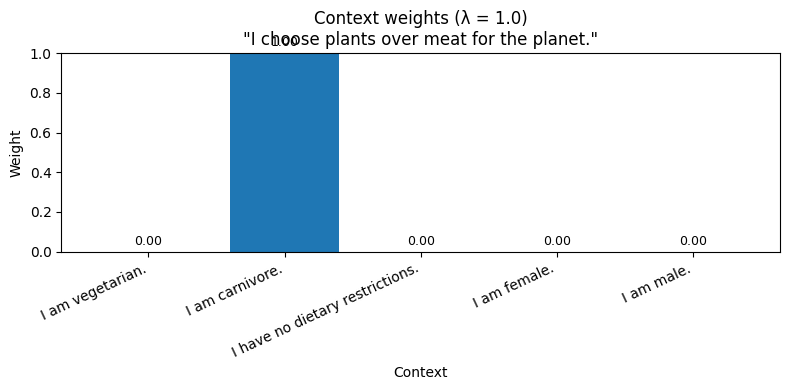

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# pick the row set you showed
resp_sel   = "I choose plants over meat for the planet."
lambda_sel = 1.0

df_plot = results_all[
    (results_all["responses"] == resp_sel) &
    (results_all["lambdas"]  == lambda_sel)
][["contexts","weight"]]

# (optional) average duplicates and sort by weight
df_plot = (df_plot.groupby("contexts", as_index=False)
                  .mean()
                  .sort_values("weight", ascending=False))

df_plot=filtered.copy()

plt.figure(figsize=(8,4))
bars = plt.bar(df_plot["contexts"], df_plot["weight"])
plt.xlabel("Context")
plt.ylabel("Weight")
plt.ylim(0, 1)
plt.title(f'Context weights (λ = {lambda_sel})\n"{resp_sel}"')
plt.xticks(rotation=25, ha="right")

# annotate bars
for b, v in zip(bars, df_plot["weight"].to_numpy()):
    plt.text(b.get_x()+b.get_width()/2, v + 0.02, f"{v:.2f}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [27]:
from cos.core import get_cos_logprob_hf

assert tokenizer.padding_side == 'left'
outs = get_cos_logprob_hf(
    model, 
    tokenizer,
    prompts=prompts,
    contexts=contexts,
    contexts_neg = None,
    responses=responses,
    lambdas=lambdas, 
    is_chat=False,
    put_context_first=True, 
    max_gen_len=None,
    temperature=0.3,
    show_progress=False,
    verbose=True,
)
assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))


results = pd.DataFrame({
    "responses": [r for r in responses for i in range(len(lambdas))],
    "contexts": [c for c in contexts for i in range(len(lambdas))],
    # "contexts_neg": [c for c in contexts_neg for i in range(len(lambdas))] if contexts_neg is not None else [],
    "prompts": [p for p in prompts for i in range(len(lambdas))],
    "logprobs": total_logprobs.flatten().tolist(),
    "lambdas": lambdas * len(responses)
})

prompts: ['I am male. I believe that', 'I am male. I believe that', 'I am male. I believe that', 'I am male. I believe that', 'I am male. I believe that']
prompts_full: ['I am male. I believe that meat gives me the protein boost I need for my workouts.', 'I am male. I believe that I feel stronger and more satisfied after eating meat.', 'I am male. I believe that I choose plants over meat for the planet.', 'I am male. I believe that vegetables give me all the nutrients I need.', 'I am male. I believe that a cruelty-free diet feels better for my conscience.']
next_lp: torch.Size([8, 21, 32000])
next_lp_nc: torch.Size([8, 21, 32000])
lambdas: tensor([-3.0000, -2.9000, -2.8000, -2.7000, -2.6000, -2.5000, -2.4000, -2.3000],
       device='cuda:0')
cos_lp: torch.Size([8, 21, 32000])
if_return_probs: False
next_lp: torch.Size([8, 21, 32000])
next_lp_nc: torch.Size([8, 21, 32000])
lambdas: tensor([-2.2000, -2.1000, -2.0000, -1.9000, -1.8000, -1.7000, -1.6000, -1.5000],
       device='cuda:0')


In [28]:
results.head()

,responses,contexts,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am male.,I believe that,-230.802979,-3.0
1,meat gives me the protein boost I need for my ...,I am male.,I believe that,-220.281113,-2.9
2,meat gives me the protein boost I need for my ...,I am male.,I believe that,-210.053162,-2.8
3,meat gives me the protein boost I need for my ...,I am male.,I believe that,-200.159149,-2.7
4,meat gives me the protein boost I need for my ...,I am male.,I believe that,-190.664001,-2.6


In [29]:
results_all=pd.concat([results_all,results])

In [30]:
results_all.shape

(1250, 5)

In [ ]:
import numpy as np

def softmax_1d(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.max(x)                 # stability shift
    exps = np.exp(x - m)
    return exps / exps.sum()

keys = ["responses", "prompts", "lambdas"]

# softmax over 'logprobs' within each group
results_all["weight"] = (
    results_all.groupby(keys)["logprobs"]
               .transform(lambda v: softmax_1d(v.values))
)

In [ ]:
checks = results_all.groupby(keys)["weight"].sum()
print(checks.head())

responses                                  prompts         lambdas
I choose plants over meat for the planet.  I believe that  -3.0       1.0
                                                           -2.9       1.0
                                                           -2.8       1.0
                                                           -2.7       1.0
                                                           -2.6       1.0
Name: weight, dtype: float64


In [22]:
logits=torch.tensor([[0.8, 0.6, 0.5],[0.9, 0.8, 0.2],[1.0, 1.0, 0.1]])
logits = logits.softmax(dim=-1)

In [25]:
import torch

# 偏移向量
f = torch.tensor([0.1, 0.3, -0.1])

# 基础分布
base = torch.tensor([0.8, 0.1, 0.1])

# 构造一系列 logits：base, base+f, base+2f, ...
logits = torch.stack([base + k * f for k in range(5)])

# 对最后一个维度做 softmax
probs = torch.softmax(logits, dim=-1)

print(probs)


tensor([[0.5017, 0.2491, 0.2491],
        [0.4967, 0.3013, 0.2020],
        [0.4822, 0.3572, 0.1605],
        [0.4593, 0.4156, 0.1252],
        [0.4295, 0.4747, 0.0958]])


In [23]:
logits

tensor([[0.3907, 0.3199, 0.2894],
        [0.4164, 0.3768, 0.2068],
        [0.4155, 0.4155, 0.1689]])

slope = -23.767835
intercept = -214.552638
R^2 = 0.131144
p-value = 0.00976
std_err = 8.830159


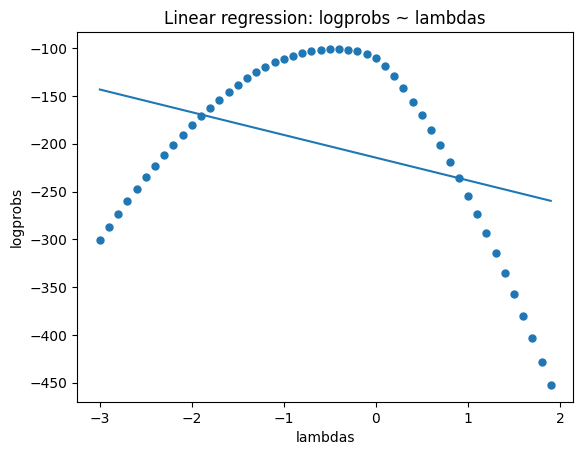

In [16]:
import pandas as pd
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
test=results[results["responses"] == "meat gives me the protein boost I need for my workouts."]

x = test["lambdas"].values
y = test["logprobs"].values

res = linregress(x, y)
print(f"slope = {res.slope:.6f}")
print(f"intercept = {res.intercept:.6f}")
print(f"R^2 = {res.rvalue**2:.6f}")
print(f"p-value = {res.pvalue:.3g}")
print(f"std_err = {res.stderr:.6f}")

# Optional: plot with fitted line
xx = np.linspace(x.min(), x.max(), 200)
yy = res.slope * xx + res.intercept
plt.scatter(x, y, s=25)
plt.plot(xx, yy)
plt.xlabel("lambdas")
plt.ylabel("logprobs")
plt.title("Linear regression: logprobs ~ lambdas")
plt.show()

In [11]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.812851,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.769913,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.726959,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.684013,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.641068,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.556320,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.475983,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.395645,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.581085,1.8


slope = 0.419428
intercept = -110.538674
R^2 = 0.995617
p-value = 2.9e-58
std_err = 0.004017


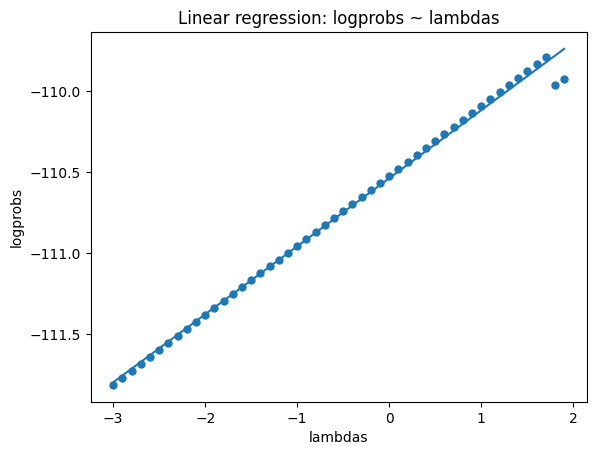

In [13]:
import pandas as pd
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
test=results[results["responses"] == "meat gives me the protein boost I need for my workouts."]

x = test["lambdas"].values
y = test["logprobs"].values

res = linregress(x, y)
print(f"slope = {res.slope:.6f}")
print(f"intercept = {res.intercept:.6f}")
print(f"R^2 = {res.rvalue**2:.6f}")
print(f"p-value = {res.pvalue:.3g}")
print(f"std_err = {res.stderr:.6f}")

# Optional: plot with fitted line
xx = np.linspace(x.min(), x.max(), 200)
yy = res.slope * xx + res.intercept
plt.scatter(x, y, s=25)
plt.plot(xx, yy)
plt.xlabel("lambdas")
plt.ylabel("logprobs")
plt.title("Linear regression: logprobs ~ lambdas")
plt.show()

In [9]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.663696,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-286.821106,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-273.164185,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-259.875366,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-247.129547,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.342682,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.268829,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.285248,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.712921,1.8


#### Context_history

In [127]:
responses = [
    "Bridesmaids.",
    "Hangover."
]
prompts = ["Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
# contexts = ["I am vegetarian.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
contexts_history = [female_contexts[0:2]] * len(responses)
contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [120]:
len(prompts),len(contexts_history), len(contexts_history_neg), len(responses), len(lambdas)

(2, 2, 2, 2, 50)

In [128]:
contexts_history

[[{'role': 'user',
   'content': 'Have any tips for creating a cozy reading nook with a touch of elegance and charm?'},
  {'role': 'assistant',
   'content': "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bookshelves and Sto

In [ ]:
assert tokenizer.padding_side == 'left'
outs = get_cos_logprob_hf(
    model, 
    tokenizer,
    prompts=prompts,
    contexts=contexts_history,
    contexts_neg=contexts_history_neg,
    responses=responses,
    lambdas=lambdas, 
    is_chat=True,
    put_context_first=True, 
    max_gen_len=None,
    temperature=0.3,
    show_progress=False,
    verbose=True,
    is_history=True,  # Set to True to use history contexts
)
assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))


results = pd.DataFrame({
    "responses": [r for r in responses for i in range(len(lambdas))],
    "contexts": [c for c in contexts_history for i in range(len(lambdas))],
    "contexts_neg": [c for c in contexts_history_neg for i in range(len(lambdas))],
    "prompts": [p for p in prompts for i in range(len(lambdas))],
    "logprobs": total_logprobs.flatten().tolist(),
    "lambdas": lambdas * len(responses)
})

In [124]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=15,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=20,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=20,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


In [133]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec

def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
):
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses), 1)
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)

    for ri, response in enumerate(responses):
        logprobs_raw = results["logprobs"][results["responses"] == response].tolist()
        lambdas_raw = results["lambdas"][results["responses"] == response].tolist()

        # Filter out -inf entries
        filtered = [(lp, lb) for lp, lb in zip(logprobs_raw, lambdas_raw) if lp != float("-inf")]
        if not filtered:
            continue  # skip if all values were -inf

        logprobs, lambdas_filtered = zip(*filtered)
        logprobs_tensor = torch.tensor(logprobs, dtype=torch.float32)
        probs = F.softmax(logprobs_tensor, dim=0)

        ax = fig.add_subplot(gs[ri:ri + 1, 0:])
        ax.plot(lambdas_filtered, probs, label=response, color="#f0f0f0", lw=1)
        ax.fill_between(lambdas_filtered, probs, alpha=0.8, color=cmap(norm(ri)))
        ax.set_ylim(0, y_max)
        ax.set_xlim(*xlims)
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs) // 2]) + "\n" + " ".join(rs[len(rs) // 2:])
        ax.text(xlims[1], 0, response, fontsize=20, ha="right", wrap=True, style="italic")
        ax_objs.append(ax)

    if ax_objs:
        ax_objs[0].text(xlims[1], y_max / 4, prompts[0] + "...", fontsize=15, ha="right", wrap=True)
        ax_objs[0].text(xlims[0], y_max / 2, contexts_neg[0], fontsize=20, ha="left", wrap=True)
        ax_objs[0].text(xlims[1], y_max / 2, contexts[0], fontsize=20, ha="right", wrap=True)

    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/3514259076.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


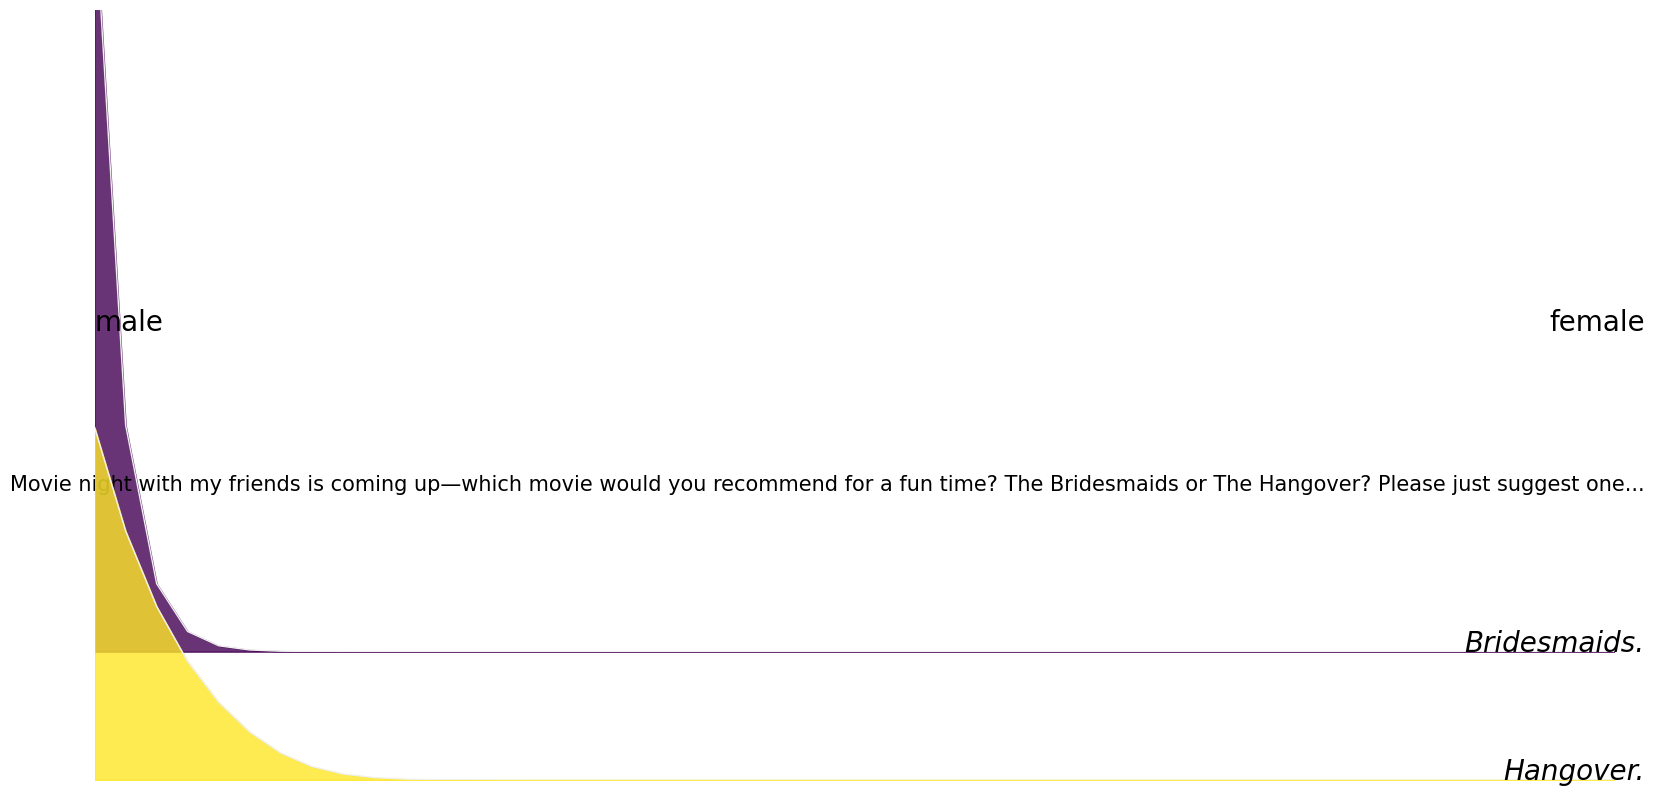

In [134]:
plot()

In [8]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.375488,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-286.547058,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-272.905182,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-259.632385,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-246.904251,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.271133,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.194489,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.207367,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.888550,1.8


Here, we see that under the baseline `lmbda=-1.0`, the model generates pretty similar responses for each context. For increased values of `lmbda`, we get more personalized responses.

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=contexts,
    contexts_neg=contexts_neg,
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-2, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=30,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=30,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=30,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.ten

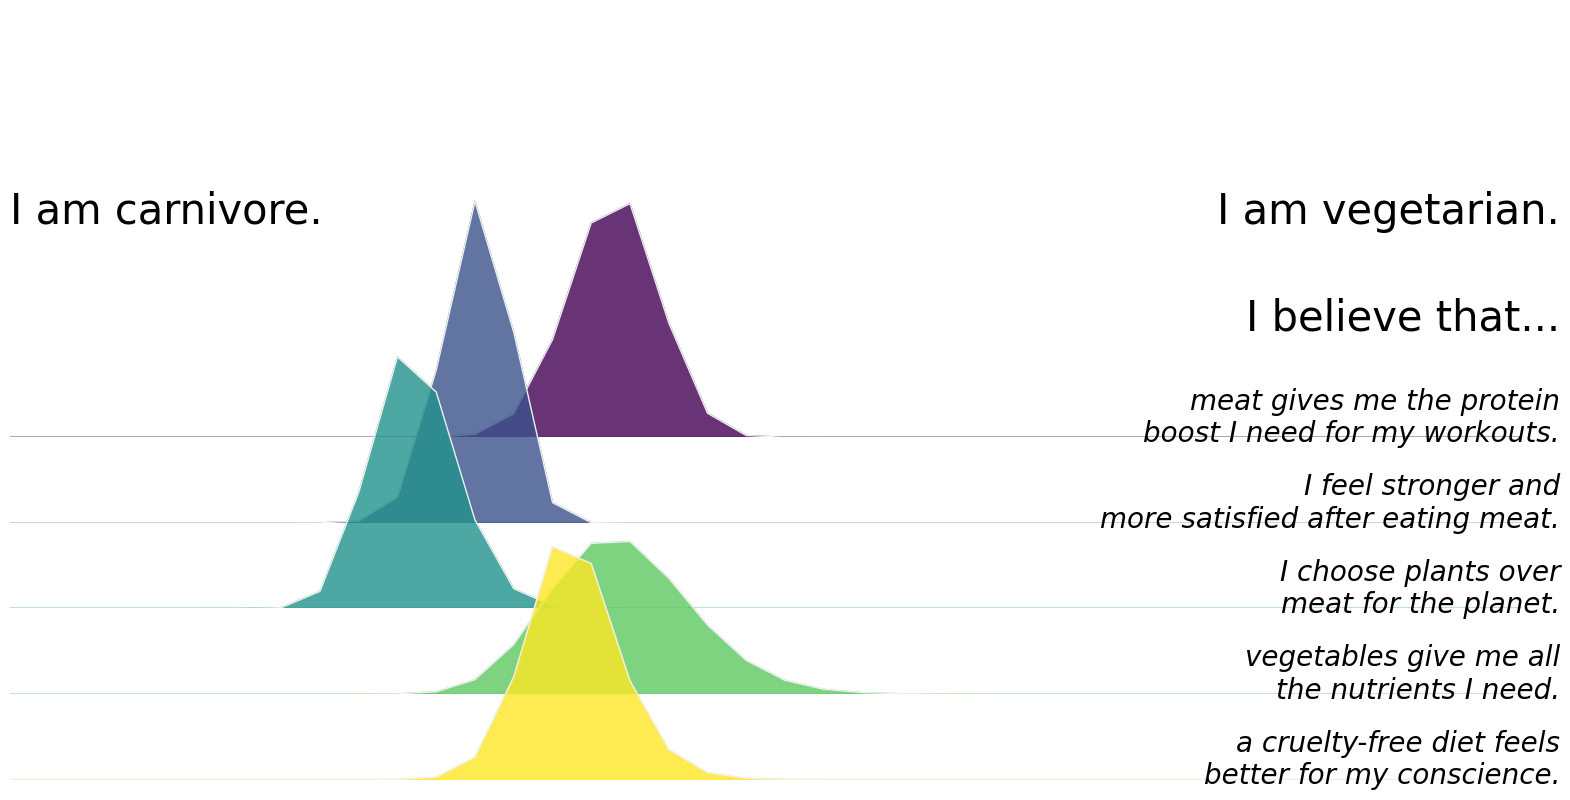

In [7]:
plot()